# d64: Aminoborane Dimer Configurations

The paper distinguishes three dimer graphs. FRUST already constructs the first one; this notebook builds the other two with the same basic `RWMol` operations used in `frust/transformers.py`.

| configuration | graph edits after combining two BH$_2$ monomers | formal-charge bookkeeping | diagnostic ring |
| --- | --- | --- | --- |
| current dimer (called *trans dimer* in the paper) | two reciprocal B-H-to-B bonds | both B: `-1`; both bridging H: `+1` | 4 atoms |
| B-H bridged dimer | one cross N-to-B bond and one cross B-H-to-B bond | both B: `-1`; donor N and bridging H: `+1` | 6 atoms |
| eight-membered ring dimer | two reciprocal cross N-to-B bonds | both B: `-1`; both donor N: `+1` | 8 atoms |

The word *trans* describes a 3D arrangement, not a different molecular graph. The current FRUST dimer is therefore a useful graph-level reference even when a later optimization does not remain trans.

## What The Paper's Drawings Mean As A Graph

Reference: J. Légaré Lavergne et al., *J. Am. Chem. Soc.* **2017**, 139, 14714-14723, Table 3 ([DOI: 10.1021/jacs.7b08143](https://doi.org/10.1021/jacs.7b08143)).

For the B-H bridged structure, one aminoborane contributes its N lone pair to the other B while one B-H bond bridges back to the first B. Together with the ortho-phenylene path, those two cross-dimer contacts close a six-membered ring.

For the eight-membered structure, each N binds the B of the opposite monomer. The two reciprocal N-B contacts close an eight-membered ring.

> [!IMPORTANT]
> RDKit does not have a special three-center B-H-B bond for this workflow. As in `transformer_mols`, the bridge is stored as two ordinary single bonds. The formal charges below are graph/valence bookkeeping for that representation; they are not a claim that the physical charge is fully localized on those atoms.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import Image, display
from rdkit import Chem
from rdkit.Chem import rdDepictor, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D

import frust as ft
from frust.transformers import transformer_mols
from frust.tsguess.matching import match_catalyst_roles
from frust.utils.mols import combine_rw_mols

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1. Start From The Catalyst FRUST Already Uses

The only input needed by the builders is the catalyst SMILES. `match_catalyst_roles` finds the ortho B-aryl-N scaffold, so the notebook does not depend on fixed atom indices.

In [2]:
CATALYST_SMILES = "CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B"
catalyst = Chem.MolFromSmiles(CATALYST_SMILES)
catalyst_roles = match_catalyst_roles(
    catalyst,
    catalyst_name=CATALYST_SMILES,
)
catalyst_roles

{'cat_B': 16, 'cat_N': 9}

In [3]:
ROLE_COLORS = {
    "B": (0.25, 0.80, 0.30),
    "N": (0.35, 0.45, 0.95),
    "H": (0.95, 0.35, 0.25),
}
ROLE_LABELS = {
    "cat_B": "B",
    "cat_N": "N",
    "cat_Ha": "Ha",
    "cat_Hb": "Hb",
    "cat1_B": "B1",
    "cat1_N": "N1",
    "cat2_B": "B2",
    "cat2_N": "N2",
    "bridge_H": "H*",
}


def draw_2d(mol, title, role_map=None, width=760, height=560):
    """Draw a 2D molecule with selected role labels.

    Parameters
    ----------
    mol : rdkit.Chem.Mol
        Molecule to draw.
    title : str
        Legend displayed below the structure.
    role_map : dict of str to int, optional
        Role names mapped to atom indices. These atoms are labelled and
        highlighted by element.
    width, height : int, optional
        Output dimensions in pixels.
    """
    draw_mol = Chem.Mol(mol)
    role_map = role_map or {}
    for role, atom_idx in role_map.items():
        draw_mol.GetAtomWithIdx(int(atom_idx)).SetProp(
            "atomNote",
            ROLE_LABELS.get(role, role),
        )

    rdDepictor.SetPreferCoordGen(True)
    rdDepictor.Compute2DCoords(draw_mol)
    highlighted = [int(atom_idx) for atom_idx in role_map.values()]
    colors = {
        atom_idx: ROLE_COLORS[draw_mol.GetAtomWithIdx(atom_idx).GetSymbol()]
        for atom_idx in highlighted
    }

    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    options = drawer.drawOptions()
    options.addAtomIndices = False
    options.annotationFontScale = 0.75
    options.bondLineWidth = 2
    drawer.DrawMolecule(
        draw_mol,
        legend=title,
        highlightAtoms=highlighted,
        highlightAtomColors=colors,
    )
    drawer.FinishDrawing()
    display(Image(data=drawer.GetDrawingText()))

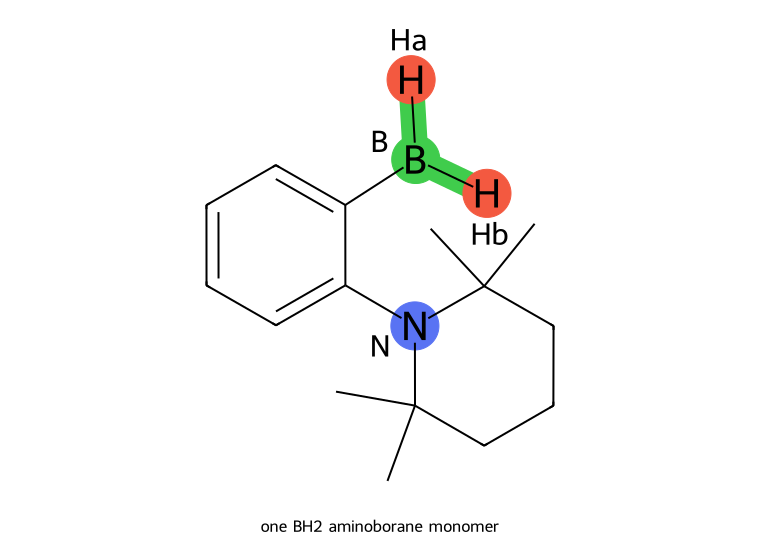

In [4]:
catalyst_with_bh = Chem.AddHs(
    catalyst,
    onlyOnAtoms=[catalyst_roles["cat_B"]],
)
boron_hydrogens = tuple(
    atom.GetIdx()
    for atom in catalyst_with_bh.GetAtomWithIdx(catalyst_roles["cat_B"]).GetNeighbors()
    if atom.GetAtomicNum() == 1
)
monomer_roles = {
    "cat_B": catalyst_roles["cat_B"],
    "cat_N": catalyst_roles["cat_N"],
    "cat_Ha": boron_hydrogens[0],
    "cat_Hb": boron_hydrogens[1],
}

draw_2d(
    catalyst_with_bh,
    "one BH2 aminoborane monomer",
    monomer_roles,
)

## Step 2. Prepare And Combine Two Monomers

This is the reusable part. Explicit H atoms are added only to B, then `combine_rw_mols` returns one editable graph and the atom-index offset for the second monomer.

In [5]:
def prepare_aminoborane_monomer(catalyst_smiles):
    """Prepare one editable aminoborane with explicit B-H atoms.

    Parameters
    ----------
    catalyst_smiles : str
        Catalyst containing one B-aryl-N scaffold and a BH2 group.

    Returns
    -------
    rdkit.Chem.RWMol
        Editable monomer with the two B-H hydrogens made explicit.
    dict
        Atom-role map containing `cat_B`, `cat_N`, and `cat_Hs`.
    """
    mol = Chem.MolFromSmiles(catalyst_smiles)
    if mol is None:
        raise ValueError(f"Could not parse catalyst SMILES: {catalyst_smiles}")

    roles = match_catalyst_roles(mol, catalyst_name=catalyst_smiles)
    mol = Chem.AddHs(mol, onlyOnAtoms=[roles["cat_B"]])
    cat_hs = tuple(
        atom.GetIdx()
        for atom in mol.GetAtomWithIdx(roles["cat_B"]).GetNeighbors()
        if atom.GetAtomicNum() == 1
    )
    if len(cat_hs) != 2:
        raise ValueError(f"Expected BH2, found {len(cat_hs)} B-H hydrogens.")

    return Chem.RWMol(mol), {**roles, "cat_Hs": cat_hs}


def combine_aminoborane_monomers(catalyst_smiles):
    """Combine two prepared monomers and offset the second role map."""
    first, first_roles = prepare_aminoborane_monomer(catalyst_smiles)
    second, second_roles = prepare_aminoborane_monomer(catalyst_smiles)
    combined, offset = combine_rw_mols(first, second)

    second_roles = {
        "cat_B": second_roles["cat_B"] + offset,
        "cat_N": second_roles["cat_N"] + offset,
        "cat_Hs": tuple(atom_idx + offset for atom_idx in second_roles["cat_Hs"]),
    }
    return combined, first_roles, second_roles


def set_formal_charges(editable, charge_by_atom):
    """Set formal charges from an atom-index to charge mapping."""
    for atom_idx, charge in charge_by_atom.items():
        editable.GetAtomWithIdx(int(atom_idx)).SetFormalCharge(int(charge))


def sanitize_editable(editable):
    """Finalize and sanitize an editable RDKit molecule."""
    mol = editable.GetMol()
    Chem.SanitizeMol(mol)
    return mol

## Step 3. Build The B-H Bridged Dimer

Use N from monomer 1 as the donor to B on monomer 2. Then take one existing B-H hydrogen from monomer 2 and add its second bond to B on monomer 1.

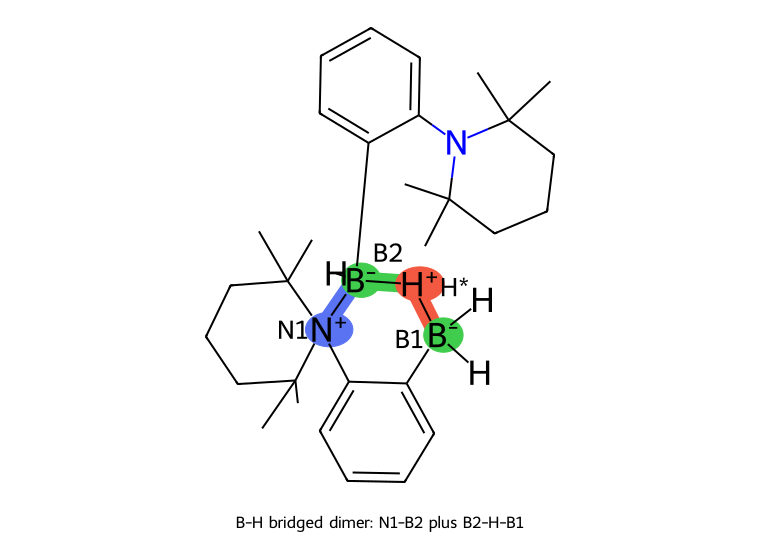

In [6]:
def build_bh_bridged_dimer(catalyst_smiles):
    """Build the asymmetric six-membered B-H bridged dimer.

    Parameters
    ----------
    catalyst_smiles : str
        Catalyst containing one B-aryl-N scaffold and a BH2 group.

    Returns
    -------
    rdkit.Chem.Mol
        Sanitized neutral dimer.
    dict
        Chemical roles for the two graph edits.
    """
    editable, first, second = combine_aminoborane_monomers(catalyst_smiles)
    bridge_h = second["cat_Hs"][0]

    # N1 -> B2 and B2-H -> B1 close the six-membered interaction ring.
    editable.AddBond(first["cat_N"], second["cat_B"], Chem.BondType.SINGLE)
    editable.AddBond(bridge_h, first["cat_B"], Chem.BondType.SINGLE)

    set_formal_charges(
        editable,
        {
            first["cat_N"]: +1,
            second["cat_B"]: -1,
            bridge_h: +1,
            first["cat_B"]: -1,
        },
    )
    roles = {
        "cat1_N": first["cat_N"],
        "cat1_B": first["cat_B"],
        "cat2_B": second["cat_B"],
        "bridge_H": bridge_h,
    }
    return sanitize_editable(editable), roles


bh_bridged, bh_roles = build_bh_bridged_dimer(CATALYST_SMILES)
draw_2d(
    bh_bridged,
    "B-H bridged dimer: N1-B2 plus B2-H-B1",
    bh_roles,
)

## Step 4. Build The Eight-Membered Ring Dimer

Here both monomers do the same thing: N from each monomer binds B on the other. No B-H hydrogen becomes bridging.

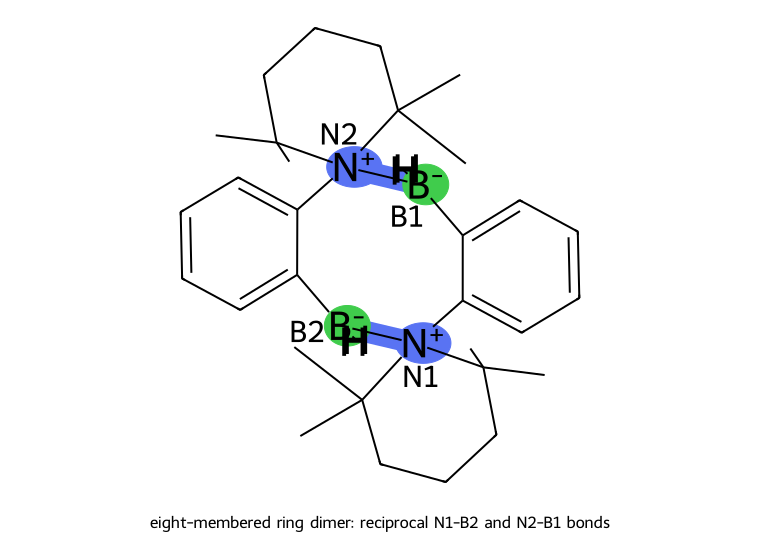

In [7]:
def build_eight_membered_ring_dimer(catalyst_smiles):
    """Build the symmetric dimer with two cross-monomer N-B bonds.

    Parameters
    ----------
    catalyst_smiles : str
        Catalyst containing one B-aryl-N scaffold and a BH2 group.

    Returns
    -------
    rdkit.Chem.Mol
        Sanitized neutral dimer.
    dict
        Chemical roles for the two cross-monomer N-B bonds.
    """
    editable, first, second = combine_aminoborane_monomers(catalyst_smiles)

    editable.AddBond(first["cat_N"], second["cat_B"], Chem.BondType.SINGLE)
    editable.AddBond(second["cat_N"], first["cat_B"], Chem.BondType.SINGLE)

    set_formal_charges(
        editable,
        {
            first["cat_N"]: +1,
            second["cat_B"]: -1,
            second["cat_N"]: +1,
            first["cat_B"]: -1,
        },
    )
    roles = {
        "cat1_N": first["cat_N"],
        "cat1_B": first["cat_B"],
        "cat2_N": second["cat_N"],
        "cat2_B": second["cat_B"],
    }
    return sanitize_editable(editable), roles


eight_membered, eight_roles = build_eight_membered_ring_dimer(CATALYST_SMILES)
draw_2d(
    eight_membered,
    "eight-membered ring dimer: reciprocal N1-B2 and N2-B1 bonds",
    eight_roles,
)

## Step 5. Compare With FRUST's Existing Dimer

The existing structure is taken directly from `transformer_mols`. The three graphs should have the same formula and zero total charge, but different interaction-ring sizes.

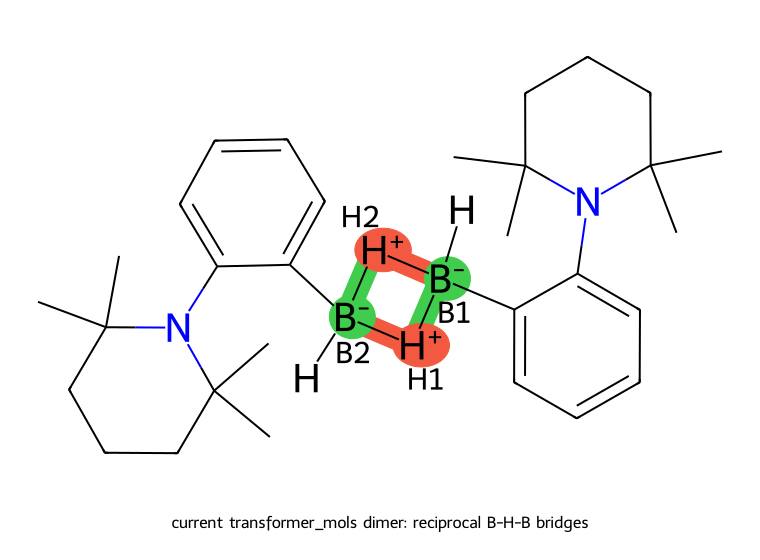

In [8]:
current_dimer = transformer_mols(
    catalyst_smiles=CATALYST_SMILES,
    select="dimer",
    show_IUPAC=False,
    key_prefix="",
)["dimer"]

current_roles = {}
for symbol in ("B", "H"):
    atom_indices = [
        atom.GetIdx()
        for atom in current_dimer.GetAtoms()
        if atom.GetSymbol() == symbol and atom.GetFormalCharge() != 0
    ]
    for number, atom_idx in enumerate(atom_indices, start=1):
        current_roles[f"{symbol}{number}"] = atom_idx
draw_2d(
    current_dimer,
    "current transformer_mols dimer: reciprocal B-H-B bridges",
    current_roles,
)

In [9]:
configurations = {
    "current_dimer": (current_dimer, current_roles, 4),
    "bh_bridged_dimer": (bh_bridged, bh_roles, 6),
    "eight_membered_ring_dimer": (eight_membered, eight_roles, 8),
}


def charged_interaction_ring_sizes(mol):
    """Return rings containing every formally charged interaction atom."""
    charged = {atom.GetIdx() for atom in mol.GetAtoms() if atom.GetFormalCharge()}
    return sorted(
        len(ring)
        for ring in Chem.GetSymmSSSR(mol)
        if charged.issubset(set(ring))
    )


summary = pd.DataFrame(
    [
        {
            "configuration": name,
            "formula": rdMolDescriptors.CalcMolFormula(mol),
            "total_formal_charge": Chem.GetFormalCharge(mol),
            "charged_atoms": sum(atom.GetFormalCharge() != 0 for atom in mol.GetAtoms()),
            "interaction_ring_sizes": charged_interaction_ring_sizes(mol),
            "expected_ring_size": expected_ring_size,
        }
        for name, (mol, _roles, expected_ring_size) in configurations.items()
    ]
)

assert summary["formula"].nunique() == 1
assert summary["total_formal_charge"].eq(0).all()
assert all(
    row.expected_ring_size in row.interaction_ring_sizes
    for row in summary.itertuples()
)
summary

,configuration,formula,total_formal_charge,charged_atoms,interaction_ring_sizes,expected_ring_size
0,current_dimer,C30H48B2N2,0,4,[4],4
1,bh_bridged_dimer,C30H48B2N2,0,4,[6],6
2,eight_membered_ring_dimer,C30H48B2N2,0,4,[8],8


In [10]:
charge_table = pd.DataFrame(
    [
        {
            "configuration": name,
            "atom_index": atom.GetIdx(),
            "element": atom.GetSymbol(),
            "formal_charge": atom.GetFormalCharge(),
            "degree": atom.GetDegree(),
        }
        for name, (mol, _roles, _ring_size) in configurations.items()
        for atom in mol.GetAtoms()
        if atom.GetFormalCharge() != 0
    ]
)
charge_table

,configuration,atom_index,element,formal_charge,degree
0,current_dimer,16,B,-1,4
1,current_dimer,17,H,1,2
2,current_dimer,35,B,-1,4
3,current_dimer,36,H,1,2
4,bh_bridged_dimer,9,N,1,4
5,bh_bridged_dimer,16,B,-1,4
6,bh_bridged_dimer,35,B,-1,4
7,bh_bridged_dimer,36,H,1,2
8,eight_membered_ring_dimer,9,N,1,4
9,eight_membered_ring_dimer,16,B,-1,4


## Step 6. Embed One 3D Starting Geometry For Each Graph

`ft.embed_mols` is used exactly as it would be before creating a Stepper dataframe. The interaction atoms are highlighted in the interactive view; click an atom to toggle its index label.

> [!NOTE]
> These ETKDG conformers verify that the graphs can be embedded and inspected. They are starting geometries, not the paper's X-ray coordinates or optimized relative-energy minima. A production comparison should optimize each configuration with the same method and solvent model.

In [11]:
def labelled_copy(mol, roles):
    """Copy a molecule and store role names as atom labels."""
    labelled = Chem.Mol(mol)
    for role, atom_idx in roles.items():
        labelled.GetAtomWithIdx(int(atom_idx)).SetProp("atomNote", role)
    return labelled


labelled_configurations = {
    name: labelled_copy(mol, roles)
    for name, (mol, roles, _ring_size) in configurations.items()
}
embedded = ft.embed_mols(
    labelled_configurations,
    n_confs=1,
    n_cores=1,
    optimization="none",
)

embedding_summary = pd.DataFrame(
    [
        {
            "configuration": name,
            "conformer_ids": cids,
            "n_atoms_with_all_H": mol.GetNumAtoms(),
        }
        for name, (mol, cids) in embedded.items()
    ]
)
assert embedding_summary["conformer_ids"].map(bool).all()
embedding_summary

,configuration,conformer_ids,n_atoms_with_all_H
0,current_dimer,[0],82
1,bh_bridged_dimer,[0],82
2,eight_membered_ring_dimer,[0],82


In [12]:
names = list(configurations)
ft.MolTo3DGrid(
    [embedded[name][0] for name in names],
    legends=[
        "current B-H-B / B-H-B dimer",
        "B-H bridged six-membered dimer",
        "eight-membered N-B / N-B dimer",
    ],
    highlightAtoms=[
        list(configurations[name][1].values())
        for name in names
    ],
    show_labels=False,
    show_charges=True,
    show_confs=False,
    columns=2,
    linked=False,
    cell_size=(520, 420),
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 7. Compare Against The Production Builders

The two development graphs should match the state ids now exposed by `transformer_mols`. The `dimers` shortcut is available through the public structure and workflow APIs.

In [ ]:
production_dimers = transformer_mols(
    ligand_smiles="CN1C=CC=C1",
    catalyst_smiles=CATALYST_SMILES,
    select="dimers",
)
{
    key.removeprefix("CN1C=CC=C1_"): (
        rdMolDescriptors.CalcMolFormula(mol),
        Chem.GetFormalCharge(mol),
    )
    for key, mol in production_dimers.items()
}

## Step 8. Use The Lowest Qualified Dimer In A Catalyst Screen

`dimer_reference="lowest"` is the default. FRUST calculates all three topologies and selects one reference per catalyst. Full calculations rank by Gibbs energy; `low_cost` and `dft_ranked` rank by electronic energy. If any topology is missing or invalid, strict selection is not made.

> [!IMPORTANT]
> The selected conformer is one exact result row. Its electronic and Gibbs energies are reused together in every barrier and profile for that catalyst.

In [ ]:
components = pd.DataFrame(
    {
        "role": ["substrate", "catalyst"],
        "smiles": ["CN1C=CC=C1", CATALYST_SMILES],
        "compound_name": ["pyrrole", "aminoborane"],
        "rpos": ["2", None],
    }
)
wf = ft.workflows.catalyst_screen(
    dataframe=components,
    method="r2scan-3c",
    dimer_reference="lowest",
)
wf.plan().query("branch == 'references'")[["state_id", "action"]]

In [ ]:
# After run = wf.run(...):
# run.dimer_references()[
#     ["catalyst_name", "state_id", "relative_energy_kcal_mol",
#      "selected", "selection_quality_status"]
# ]

## Takeaway

Both missing configurations fit the current transformer model without a new molecular representation:

1. add explicit B-H atoms;
2. combine two monomers and offset the second atom map;
3. add two cross-monomer bonds;
4. assign compensating formal charges;
5. sanitize and embed.

The 2D ring checks distinguish the three topologies unambiguously. Their 3D conformers are starting structures to optimize, rather than separate *cis* or *trans* graphs. In catalyst screens, `dimer_reference="lowest"` keeps all candidates auditable while using one strict per-catalyst reference consistently.